In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [ ]:
n = 1000

data = pd.DataFrame({
    'Student_ID': range(1, n+1),

    'Source': np.random.choice(
        ['LinkedIn', 'Instagram', 'Website', 'Referral'],
        n),

    'Course': np.random.choice(
        ['Data Analytics',
         'Web Development',
         'Python',
         'AI/ML'],
        n),

    'Gender': np.random.choice(
        ['Male', 'Female'],
        n),

    'Applied': np.random.choice(
        ['Yes', 'No'],
        n,
        p=[0.8, 0.2])
})

In [ ]:
data['Assessment'] = np.where(
    data['Applied']=='Yes',
    np.random.choice(['Yes','No'],
                     n,
                     p=[0.75,0.25]),
    'No'
)

data['Interview'] = np.where(
    data['Assessment']=='Yes',
    np.random.choice(['Yes','No'],
                     n,
                     p=[0.7,0.3]),
    'No'
)

data['Selected'] = np.where(
    data['Interview']=='Yes',
    np.random.choice(['Yes','No'],
                     n,
                     p=[0.65,0.35]),
    'No'
)

data['Completed'] = np.where(
    data['Selected']=='Yes',
    np.random.choice(['Yes','No'],
                     n,
                     p=[0.8,0.2]),
    'No'
)

data.head()

,Student_ID,Source,Course,Gender,Applied,Assessment,Interview,Selected,Completed
0,1,Website,Web Development,Male,Yes,No,No,No,No
1,2,Referral,Python,Female,Yes,No,No,No,No
2,3,LinkedIn,Data Analytics,Female,Yes,Yes,No,No,No
3,4,Website,Data Analytics,Female,Yes,No,No,No,No
4,5,Website,Data Analytics,Female,Yes,Yes,No,No,No


In [ ]:
print(data.shape)

print(data.info())

print(data.describe(include='object'))

(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  1000 non-null   int64 
 1   Source      1000 non-null   object
 2   Course      1000 non-null   object
 3   Gender      1000 non-null   object
 4   Applied     1000 non-null   object
 5   Assessment  1000 non-null   object
 6   Interview   1000 non-null   object
 7   Selected    1000 non-null   object
 8   Completed   1000 non-null   object
dtypes: int64(1), object(8)
memory usage: 70.4+ KB
None
          Source          Course Gender Applied Assessment Interview Selected  \
count       1000            1000   1000    1000       1000      1000     1000   
unique         4               4      2       2          2         2        2   
top     Referral  Data Analytics   Male     Yes        Yes        No       No   
freq         280             267    501     807        600       

In [ ]:
print(data.isnull().sum())

Student_ID    0
Source        0
Course        0
Gender        0
Applied       0
Assessment    0
Interview     0
Selected      0
Completed     0
dtype: int64


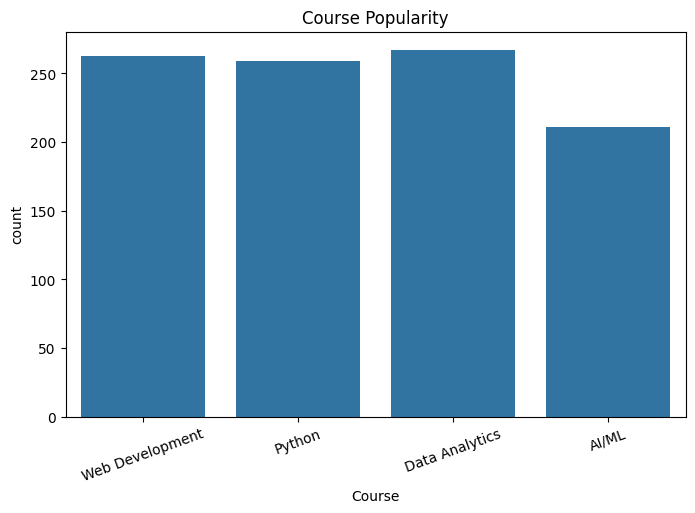

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Course',
    data=data)

plt.title("Course Popularity")
plt.xticks(rotation=20)
plt.show()

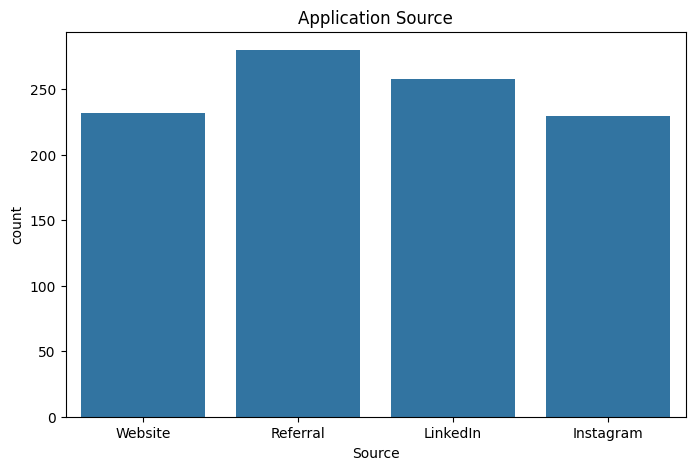

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Source',
    data=data)

plt.title("Application Source")
plt.show()

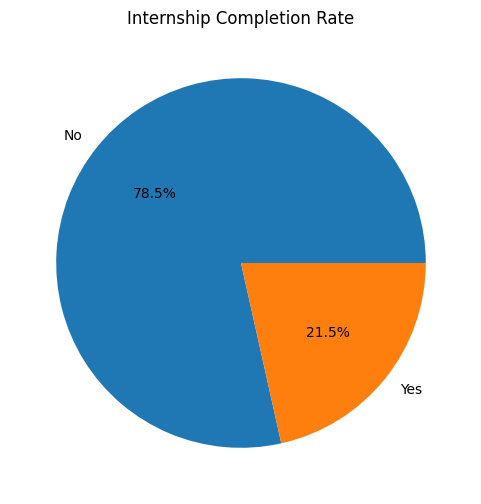

In [ ]:
completion = data['Completed'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    completion,
    labels=completion.index,
    autopct='%1.1f%%')

plt.title("Internship Completion Rate")
plt.show()

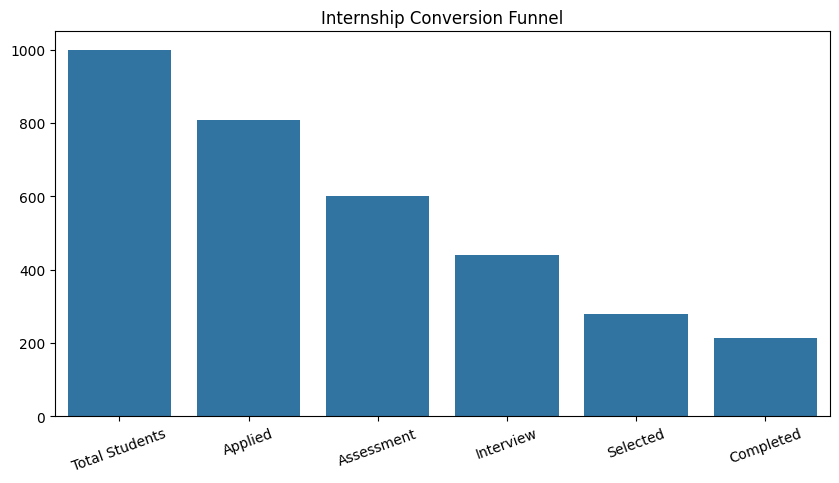

In [ ]:
funnel = [
    len(data),

    len(data[data['Applied']=='Yes']),

    len(data[data['Assessment']=='Yes']),

    len(data[data['Interview']=='Yes']),

    len(data[data['Selected']=='Yes']),

    len(data[data['Completed']=='Yes'])
]

stages = [
    'Total Students',
    'Applied',
    'Assessment',
    'Interview',
    'Selected',
    'Completed'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=stages,
    y=funnel)

plt.title("Internship Conversion Funnel")
plt.xticks(rotation=20)
plt.show()

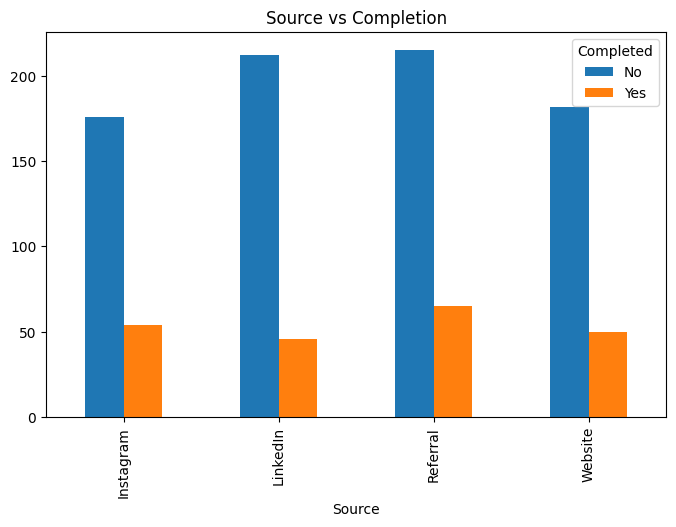

In [ ]:
source_completion = pd.crosstab(
    data['Source'],
    data['Completed'])

source_completion.plot(
    kind='bar',
    figsize=(8,5))

plt.title("Source vs Completion")
plt.show()

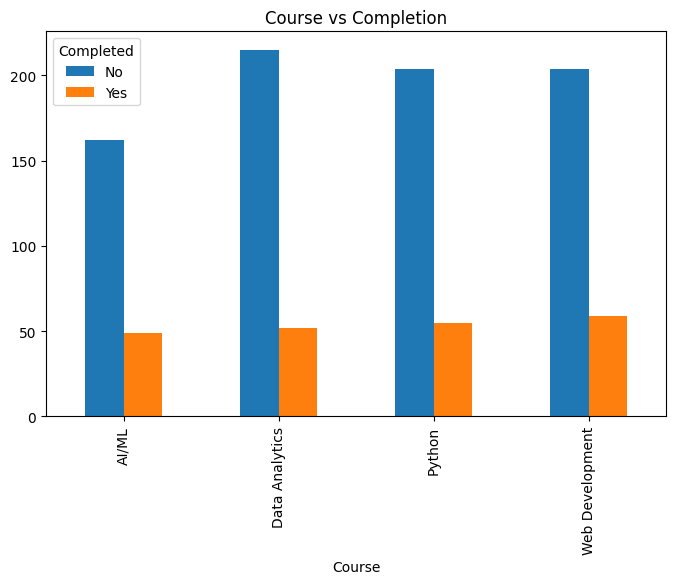

In [ ]:
course_completion = pd.crosstab(
    data['Course'],
    data['Completed'])

course_completion.plot(
    kind='bar',
    figsize=(8,5))

plt.title("Course vs Completion")
plt.show()

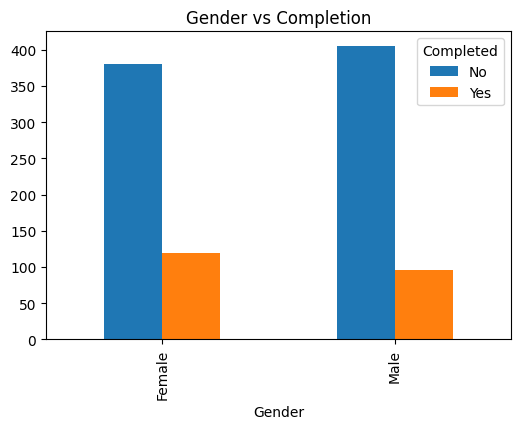

In [ ]:
gender_completion = pd.crosstab(
    data['Gender'],
    data['Completed'])

gender_completion.plot(
    kind='bar',
    figsize=(6,4))

plt.title("Gender vs Completion")
plt.show()

In [ ]:
print("Total Students :", len(data))
print("Completed Internship :",
      len(data[data['Completed']=='Yes']))

Total Students : 1000
Completed Internship : 215
